# Figure 7: ImageNet Prompt-Template Scaling

This notebook loads the ImageNet `similarities_targets.pt` tensor, computes metrics using all available samples, resamples template orders, fits `f(x) = a + b / x` on averaged points, and saves the three Fig. 7 PDF panels.


In [1]:
# Shared imports, plotting style, and metric helpers for Fig. 7.
import pathlib
import time

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

mpl.rcParams['axes.linewidth'] = 1.3
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})


In [2]:
# Resolve data and output paths from either the figures directory or the repository root.
def resolve_path(local_path):
    path = pathlib.Path(local_path)
    if path.exists():
        return path
    repo_path = pathlib.Path("..") / path
    if repo_path.exists():
        return repo_path
    figures_path = pathlib.Path("figures") / path
    if figures_path.exists():
        return figures_path
    return path


DATA_PATH = resolve_path("data/imagenet-data/similarities_targets.pt")
OUTPUT_DIR = resolve_path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH, OUTPUT_DIR


(WindowsPath('data/imagenet-data/similarities_targets.pt'),
 WindowsPath('output'))

# Compute ImageNet metrics

Each resample is a random permutation of the 80 templates. Prefixes of length `M` form random `M`-template combinations, and every combination is evaluated on the full 50,000-example ImageNet validation set in sequential batches.

In [3]:
# Resample template orders, compute prefix metrics, and average across resamples.
N_RESAMPLES = 32
RANDOM_SEED = 0


def make_template_permutations(num_templates_total, n_resamples, seed):
    rng = np.random.default_rng(seed)
    permutations = [rng.permutation(num_templates_total) for _ in range(n_resamples)]
    return torch.as_tensor(np.stack(permutations), dtype=torch.long)


def compute_imagenet_metrics(data_path, n_resamples=N_RESAMPLES, seed=RANDOM_SEED, batch_size=1024):
    data = torch.load(str(data_path), map_location="cpu", mmap=True, weights_only=False)
    similarities = data["similarities"]
    targets = data["targets"]
    num_templates = torch.as_tensor(data["num_templates_list"], dtype=torch.long)
    prefix_positions = num_templates - 1

    num_samples = targets.numel()
    num_prefixes = num_templates.numel()
    num_templates_total = similarities.shape[1]
    permutations = make_template_permutations(num_templates_total, n_resamples, seed)

    loss_samples = np.zeros((n_resamples, num_prefixes), dtype=np.float64)
    acc1_samples = np.zeros((n_resamples, num_prefixes), dtype=np.float64)
    acc5_samples = np.zeros((n_resamples, num_prefixes), dtype=np.float64)
    denominator = num_templates.to(dtype=similarities.dtype).view(1, -1, 1)

    start_time = time.time()
    with torch.inference_mode():
        for sample_idx, permutation in enumerate(permutations):
            sample_start_time = time.time()
            loss_sum = torch.zeros(num_prefixes, dtype=torch.float64)
            top1_sum = torch.zeros(num_prefixes, dtype=torch.float64)
            top5_sum = torch.zeros(num_prefixes, dtype=torch.float64)

            for start in range(0, num_samples, batch_size):
                end = min(start + batch_size, num_samples)
                labels = targets[start:end]
                cumulative = similarities[start:end].index_select(1, permutation).cumsum(dim=1)
                logits = cumulative.index_select(1, prefix_positions) / denominator

                flat_logits = logits.reshape(-1, logits.shape[-1])
                flat_labels = labels[:, None].expand(-1, num_prefixes).reshape(-1)
                losses = F.cross_entropy(flat_logits, flat_labels, reduction="none")
                losses = losses.view(end - start, num_prefixes)

                top5 = logits.topk(5, dim=-1).indices
                loss_sum += losses.sum(dim=0).double()
                top1_sum += top5[..., 0].eq(labels[:, None]).sum(dim=0).double()
                top5_sum += top5.eq(labels[:, None, None]).any(dim=-1).sum(dim=0).double()

            loss_samples[sample_idx] = (loss_sum / num_samples).numpy()
            acc1_samples[sample_idx] = (top1_sum / num_samples * 100).numpy()
            acc5_samples[sample_idx] = (top5_sum / num_samples * 100).numpy()
            sample_elapsed = time.time() - sample_start_time
            print(f"Resample {sample_idx + 1:02d}/{n_resamples}: processed all {num_samples} examples in {sample_elapsed:.1f}s")

    elapsed = time.time() - start_time
    print(f"Processed the full {num_samples}-example dataset for {n_resamples} template resamples in {elapsed:.1f}s")
    return {
        "num_templates": num_templates.numpy(),
        "loss_samples": loss_samples,
        "acc1_samples": acc1_samples,
        "acc5_samples": acc5_samples,
        "loss": loss_samples.mean(axis=0),
        "acc1": acc1_samples.mean(axis=0),
        "acc5": acc5_samples.mean(axis=0),
        "loss_std": loss_samples.std(axis=0, ddof=1),
        "acc1_std": acc1_samples.std(axis=0, ddof=1),
        "acc5_std": acc5_samples.std(axis=0, ddof=1),
    }


metrics = compute_imagenet_metrics(DATA_PATH)
for name in ["loss", "acc1", "acc5"]:
    print(f"{name}: M=1 {metrics[name][0]:.4f}, M=80 {metrics[name][-1]:.4f}")


Resample 01/32: processed all 50000 examples in 7.3s


Resample 02/32: processed all 50000 examples in 3.6s


Resample 03/32: processed all 50000 examples in 3.5s


Resample 04/32: processed all 50000 examples in 3.5s


Resample 05/32: processed all 50000 examples in 3.5s


...

Resample 29/32: processed all 50000 examples in 3.8s


Resample 30/32: processed all 50000 examples in 3.7s


Resample 31/32: processed all 50000 examples in 3.7s


Resample 32/32: processed all 50000 examples in 3.7s
Processed the full 50000-example dataset for 32 template resamples in 117.4s


loss: M=1 5.0502, M=80 4.0845
acc1: M=1 30.8468, M=80 36.7620
acc5: M=1 57.7924, M=80 64.4220


# Plot Fig7

The inverse curve is fit only to the resampled mean point at each template count, not to the individual resample curves.

In [4]:
# Fit f(x) = a + b / x only to averaged metric points and compute R^2.
def fit_inverse_curve_on_mean_points(x_values, y_values):
    x_values = np.asarray(x_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)
    if y_values.ndim != 1:
        raise ValueError("Fit only the averaged metric points, not per-resample values.")
    b, a = np.polyfit(1 / x_values, y_values, 1)
    fitted = a + b / x_values
    residual_sum_squares = np.sum((y_values - fitted) ** 2)
    total_sum_squares = np.sum((y_values - y_values.mean()) ** 2)
    r_squared = 1 - residual_sum_squares / total_sum_squares
    return {"a": a, "b": b, "r2": r_squared}


def plot_template_metric(x_values, y_values, ylabel, output_name, fit_result, legend_loc="best"):
    x_values = np.asarray(x_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)

    x_fit = np.linspace(x_values.min(), x_values.max(), 200)
    y_fit = fit_result["a"] + fit_result["b"] / x_fit

    fig, ax = plt.subplots(figsize=(4, 3), dpi=300)
    ax.plot(
        x_values,
        y_values,
        label="Actual Data",
        color="tab:blue",
        linewidth=2,
        marker="o",
        markersize=4,
        alpha=0.9,
    )
    ax.plot(
        x_fit,
        y_fit,
        label="Fitted Curve",
        color="tab:orange",
        linewidth=2,
        linestyle="--",
    )
    ax.set_xlabel("Number of Templates", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, ls="--", alpha=0.5)

    legend = ax.legend(
        loc=legend_loc,
        frameon=True,
        fancybox=False,
        framealpha=1,
        facecolor="white",
        edgecolor="black",
    )
    legend.get_frame().set_linewidth(1.0)

    fig.savefig(OUTPUT_DIR / output_name, format="pdf", dpi=300, bbox_inches="tight")
    return fig, ax


loss: f(x) = 4.071843 + 0.971726/x, R^2 = 0.9983
acc1: f(x) = 36.703820 + -6.165772/x, R^2 = 0.9873
acc5: f(x) = 64.407444 + -6.836882/x, R^2 = 0.9919


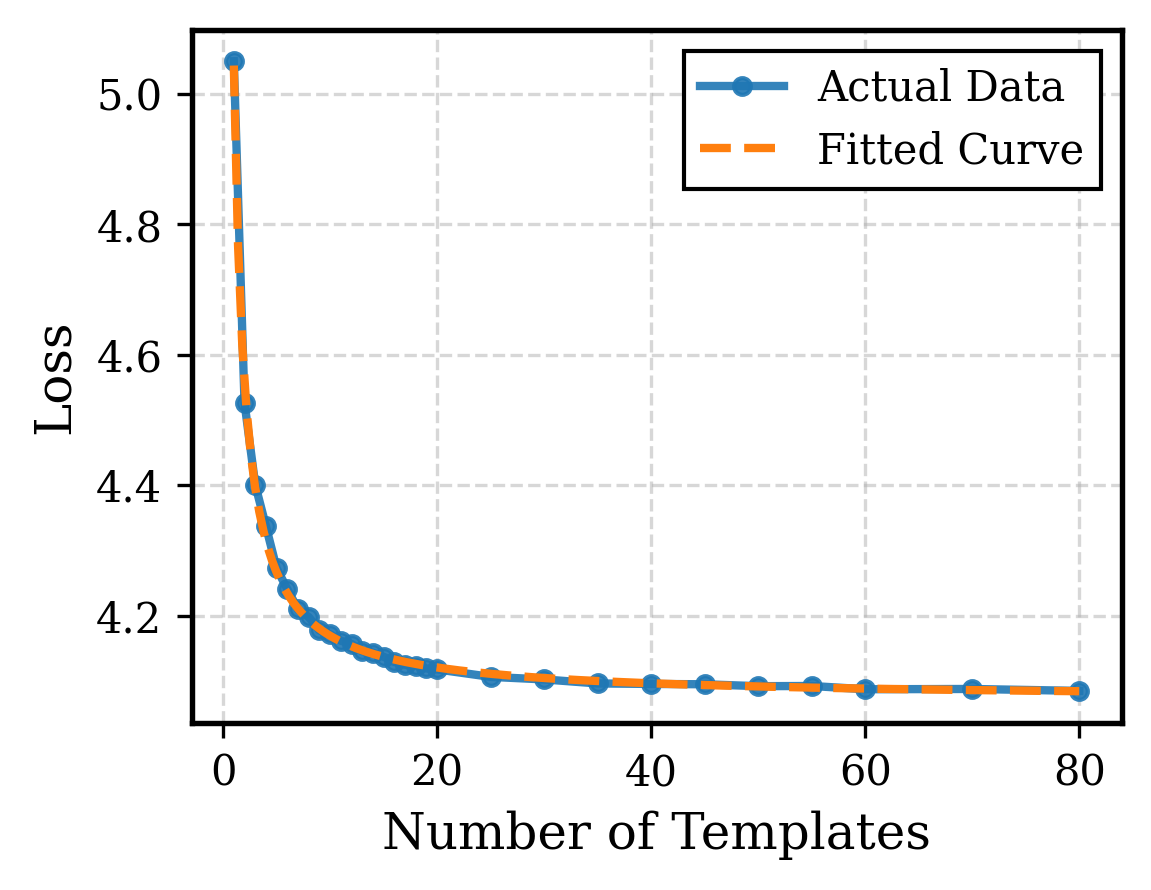

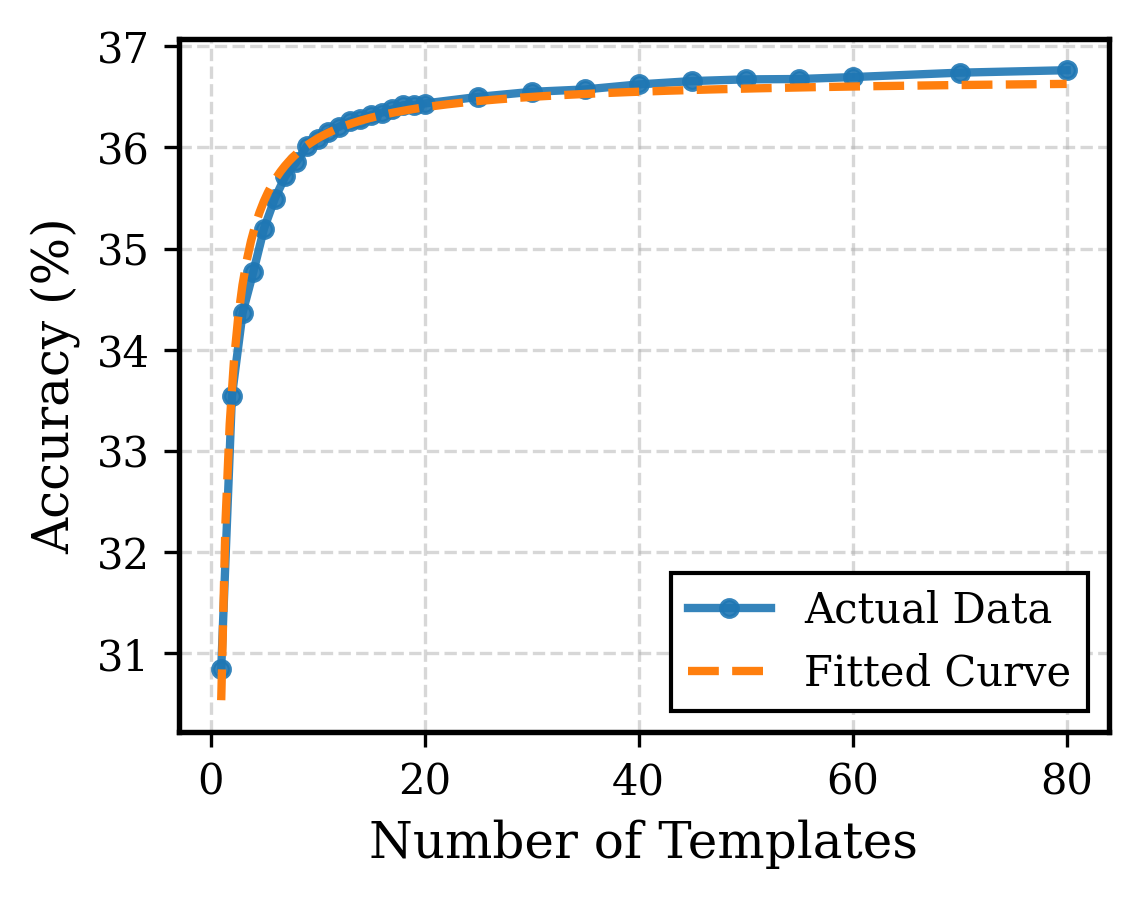

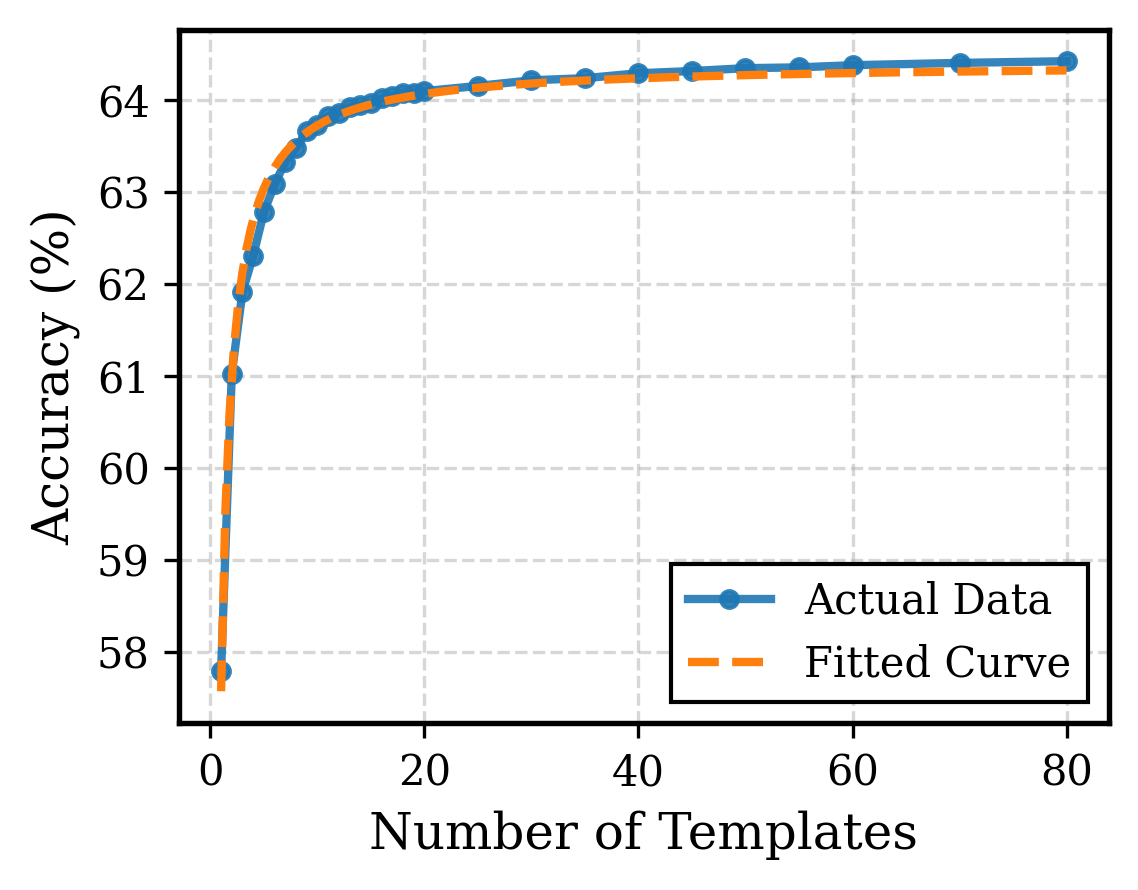

In [5]:
# Render loss, top-1 accuracy, and top-5 accuracy panels and save Fig. 7 PDFs.
mean_points = {
    "loss": metrics["loss"],
    "acc1": metrics["acc1"],
    "acc5": metrics["acc5"],
}

fit_results = {
    name: fit_inverse_curve_on_mean_points(metrics["num_templates"], y_values)
    for name, y_values in mean_points.items()
}

for name, result in fit_results.items():
    print(f"{name}: f(x) = {result['a']:.6f} + {result['b']:.6f}/x, R^2 = {result['r2']:.4f}")

fig_loss, ax_loss = plot_template_metric(
    metrics["num_templates"],
    metrics["loss"],
    "Loss",
    "Fig7-a-imagenet-loss.pdf",
    fit_results["loss"],
    legend_loc="upper right",
)

fig_acc1, ax_acc1 = plot_template_metric(
    metrics["num_templates"],
    metrics["acc1"],
    "Accuracy (%)",
    "Fig7-b-imagenet-acc1.pdf",
    fit_results["acc1"],
    legend_loc="lower right",
)

fig_acc5, ax_acc5 = plot_template_metric(
    metrics["num_templates"],
    metrics["acc5"],
    "Accuracy (%)",
    "Fig7-c-imagenet-acc5.pdf",
    fit_results["acc5"],
    legend_loc="lower right",
)
